# Logistic Regression

**Goal:** Classify breast-cancer tumours as **Malignant (1)** or **Benign (0)** using 30 numeric features.

**Dataset:** Wisconsin Breast Cancer dataset — 569 samples, 30 numeric features (mean, SE, and worst values for radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

Unlike regression models that predict a continuous value, Logistic Regression outputs a **probability** and then thresholds it (default: 0.5) to assign a class label.

### Read the csv

`data.info()` shows 569 rows, 33 columns. Two columns are useless for modelling:
- `id` — arbitrary patient identifier
- `Unnamed: 32` — an empty trailing column created by the CSV export

They will be dropped in the next cell.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [2]:
data.drop(["id","Unnamed: 32"],axis= 1,inplace = True) # we dont need this variables for the model

We also **encode** the target column: `'M'` (Malignant) → `1`, `'B'` (Benign) → `0`.  
Most ML algorithms require numeric labels.

In [3]:
data.diagnosis = [  1 if each == "M" else 0 for each in data.diagnosis]

In [4]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
y = data.diagnosis.values
x_data = data.drop(["diagnosis"],axis = 1)

### Normalization

**Min-Max Normalization** rescales each feature to the range `[0, 1]`:  
`x_norm = (x − x_min) / (x_max − x_min)`

This is critical for algorithms sensitive to feature scale (e.g. gradient-descent-based methods). Without it, a feature with large absolute values (like `area_mean`) would dominate.

In [6]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())

In [7]:
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [10]:
x_train = x_train.T
y_train = y_train.T
x_test = x_test.T
y_test = y_test.T

In [11]:
x_train 

,68,181,63,248,60,15,290,137,155,517,...,330,214,466,121,20,71,106,270,435,102
radius_mean,0.096928,0.667755,0.103744,0.173648,0.150930,0.357755,0.351602,0.210564,0.249373,0.610961,...,0.428274,0.341190,0.291495,0.552747,0.288655,0.090255,0.220503,0.345923,0.331251,0.246060
texture_mean,0.257694,0.570172,0.140345,0.524518,0.174839,0.602976,0.338857,0.192087,0.278323,0.356781,...,0.196145,0.476835,0.373013,0.250592,0.202908,0.166723,0.291512,0.240446,0.335137,0.365573
perimeter_mean,0.103656,0.683505,0.106489,0.167369,0.143459,0.365835,0.360998,0.202267,0.238270,0.599198,...,0.428512,0.339161,0.291549,0.536314,0.289130,0.103656,0.216847,0.321401,0.327068,0.231014
area_mean,0.045387,0.495228,0.049799,0.086320,0.071432,0.218579,0.215270,0.108717,0.134380,0.454083,...,0.275589,0.198176,0.166872,0.395970,0.159703,0.042630,0.114104,0.207466,0.193425,0.133701
smoothness_mean,0.487226,0.554934,0.221901,0.396678,0.548614,0.553128,0.315428,0.395053,0.306130,0.461045,...,0.381692,0.379164,0.308026,0.476393,0.495351,0.408053,0.555836,0.105263,0.481809,0.248262
compactness_mean,0.373965,0.809214,0.208975,0.162444,0.187811,0.429790,0.454635,0.151862,0.145421,0.342372,...,0.361082,0.341145,0.274584,0.277958,0.330102,0.410159,0.252500,0.022606,0.288080,0.064413
concavity_mean,0.733365,0.582709,0.140300,0.055740,0.025398,0.384021,0.319119,0.082076,0.091026,0.330600,...,0.282099,0.261246,0.254217,0.341378,0.107029,0.201640,0.165651,0.016987,0.263824,0.055834
concave points_mean,0.217445,0.743539,0.108350,0.080268,0.064115,0.366004,0.328131,0.142893,0.115855,0.468738,...,0.349950,0.321173,0.174453,0.430666,0.154573,0.142744,0.173211,0.031064,0.321223,0.087972
symmetry_mean,0.530808,0.674242,0.646970,0.422727,0.850000,0.627778,0.330303,0.340404,0.459596,0.374747,...,0.364646,0.593434,0.253535,0.457576,0.458081,0.425253,0.374242,0.226263,0.307576,0.342929
fractal_dimension_mean,0.642376,0.505897,0.414280,0.280750,0.413648,0.438290,0.462511,0.183024,0.259478,0.251053,...,0.206403,0.302654,0.215670,0.256318,0.382266,0.839090,0.320977,0.080034,0.326032,0.143429


In [12]:
def initialize_weights_and_bias(dimension):
    w = np.full((dimension,1),0.01)
    b = 0.0
    return w,b

In [13]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    y_head = 1 / (1 + np.exp(-z))
    return y_head

In [14]:
def forward_backward_propagation(w,b,x_train,y_train):
    # forward propagation
    z = np.dot(w.T,x_train) + b
    y_head = sigmoid(z)
    loss = -y_train*np.log(y_head + 1e-8)-(1-y_train)*np.log(1-y_head + 1e-8)
    cost = (np.sum(loss))/x_train.shape[1]      # x_train.shape[1]  is for scaling
    
    # backward propagation
    derivative_weight = (np.dot(x_train,((y_head-y_train).T)))/x_train.shape[1] # x_train.shape[1]  is for scaling
    derivative_bias = np.sum(y_head-y_train)/x_train.shape[1]                 # x_train.shape[1]  is for scaling
    gradients = {"derivative_weight": derivative_weight,"derivative_bias": derivative_bias}
    return cost,gradients

### Update weights and bias

In [15]:
# Updating(learning) parameters
def update(w, b, x_train, y_train, learning_rate,number_of_iterarion):
    cost_list = []
    cost_list2 = []
    index = []
    # updating(learning) parameters is number_of_iterarion times
    for i in range(number_of_iterarion):
        # make forward and backward propagation and find cost and gradients
        cost,gradients = forward_backward_propagation(w,b,x_train,y_train)
        cost_list.append(cost)
        # lets update
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
        if i % 10 == 0:
            cost_list2.append(cost)
            index.append(i)
            print ("Cost after iteration %i: %f" %(i, cost))
    # we update(learn) parameters weights and bias
    parameters = {"weight": w,"bias": b}
    plt.plot(index,cost_list2)
    plt.xticks(index,rotation='vertical')
    plt.xlabel("Number of Iterarion")
    plt.ylabel("Cost")
    plt.show()
    return parameters, gradients, cost_list
#parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate = 0.009,number_of_iterarion = 200)

### Predict

In [16]:
def predict(w,b,x_test):
    # x_test is a input for forward propagation
    z = sigmoid(np.dot(w.T,x_test)+b)
    Y_prediction = np.zeros((1,x_test.shape[1]))
    # if z is bigger than 0.5, our prediction is sign one (y_head=1),
    # if z is smaller than 0.5, our prediction is sign zero (y_head=0),
    for i in range(z.shape[1]):
        if z[0,i]<= 0.5:
            Y_prediction[0,i] = 0
        else:
            Y_prediction[0,i] = 1

    return Y_prediction
# predict(parameters["weight"],parameters["bias"],x_test)

Cost after iteration 0: 0.692977
Cost after iteration 10: 0.427285
Cost after iteration 20: 0.334585
Cost after iteration 30: 0.286756
Cost after iteration 40: 0.256943
Cost after iteration 50: 0.236210
Cost after iteration 60: 0.220733
Cost after iteration 70: 0.208597
Cost after iteration 80: 0.198733
Cost after iteration 90: 0.190494
Cost after iteration 100: 0.183466
Cost after iteration 110: 0.177370
Cost after iteration 120: 0.172009
Cost after iteration 130: 0.167242
Cost after iteration 140: 0.162962
Cost after iteration 150: 0.159090
Cost after iteration 160: 0.155562
Cost after iteration 170: 0.152329
Cost after iteration 180: 0.149351
Cost after iteration 190: 0.146595
Cost after iteration 200: 0.144035
Cost after iteration 210: 0.141649
Cost after iteration 220: 0.139417
Cost after iteration 230: 0.137323
Cost after iteration 240: 0.135353
Cost after iteration 250: 0.133497
Cost after iteration 260: 0.131743
Cost after iteration 270: 0.130082
Cost after iteration 280: 0.128

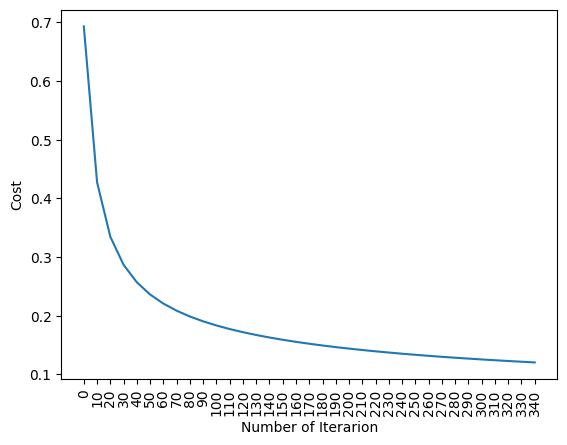

train accuracy: 97.36263736263736 %
test accuracy: 96.49122807017544 %


In [17]:
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate ,  num_iterations):
    # initialize
    dimension =  x_train.shape[0]  # that is 4096
    w,b = initialize_weights_and_bias(dimension)
    # do not change learning rate
    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate,num_iterations)
    
    y_prediction_test = predict(parameters["weight"],parameters["bias"],x_test)
    y_prediction_train = predict(parameters["weight"],parameters["bias"],x_train)

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_train - y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))
    
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 1.7, num_iterations = 350)

### Logistic Regression with sklearn

In [18]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='saga', max_iter=1000)
lr.fit(x_train.T, y_train.T)
print("test accuracy is : {}".format(lr.score(x_test.T, y_test.T)))

test accuracy is : 0.9824561403508771


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
